In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [17]:
# Leggi la lista dei ticker dal file
def load_tickers_only(filename='tickers.txt'):
    """Carica solo i ticker dal file di configurazione"""
    tickers = []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split(',')
                if len(parts) == 2:
                    ticker = parts[1].strip()
                    tickers.append(ticker)
    return tickers

TICKERS = load_tickers_only('tickers.txt')

# Crea la cartella result se non esiste
os.makedirs('result', exist_ok=True)

GENERAZIONE GRAFICI TRIMESTRALI (10-Q)


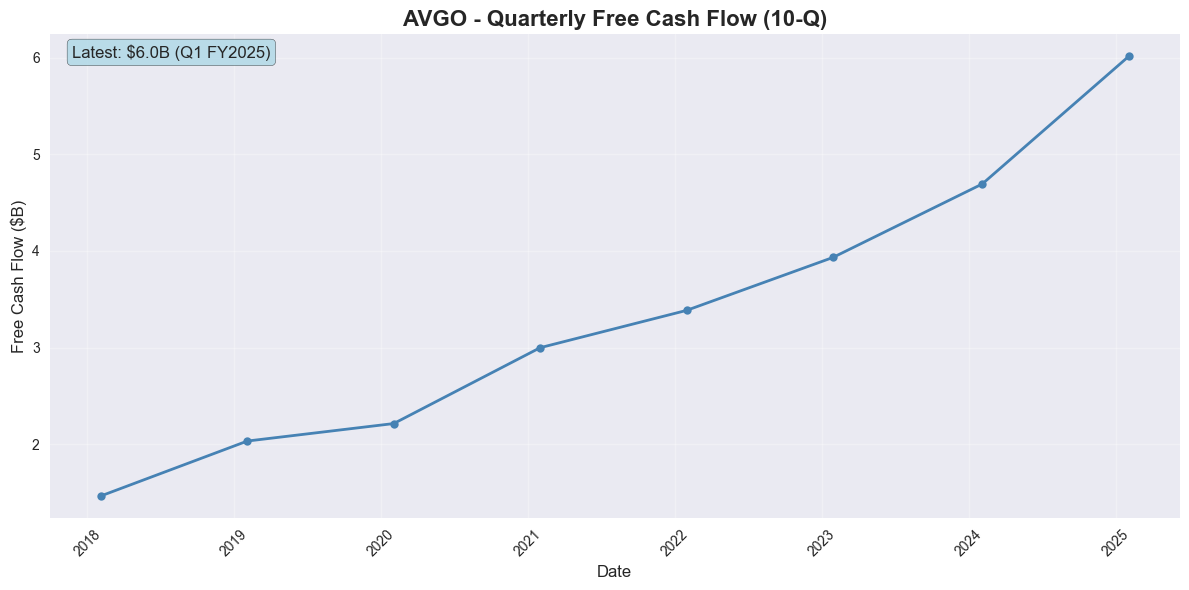

✓ Grafico 10-Q salvato: result/AVGO_fcf_10Q.png


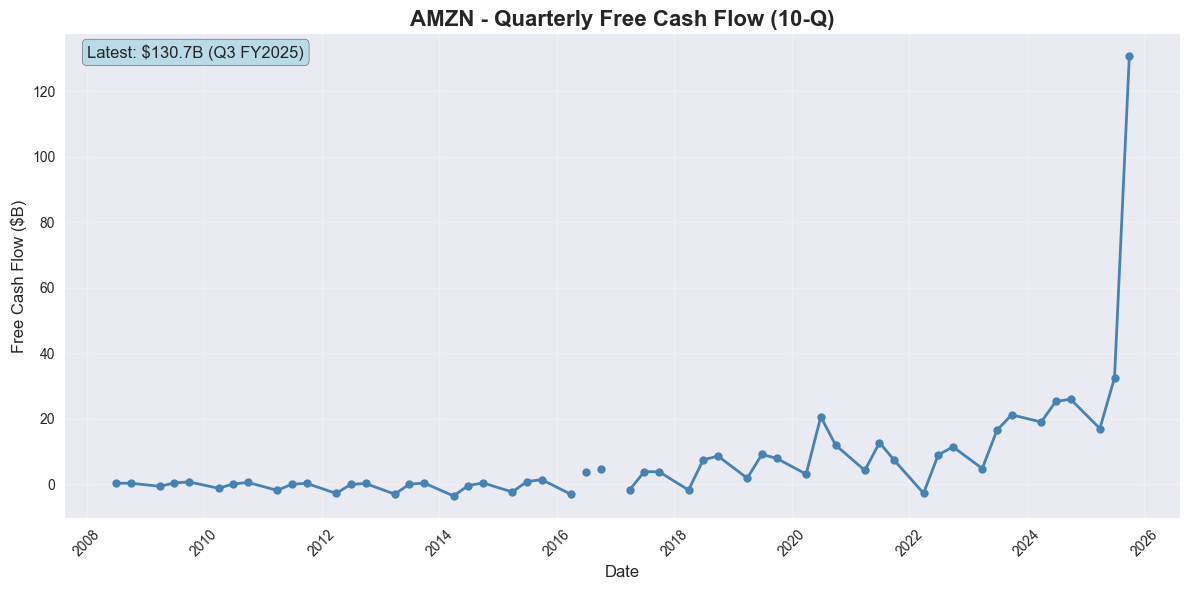

✓ Grafico 10-Q salvato: result/AMZN_fcf_10Q.png


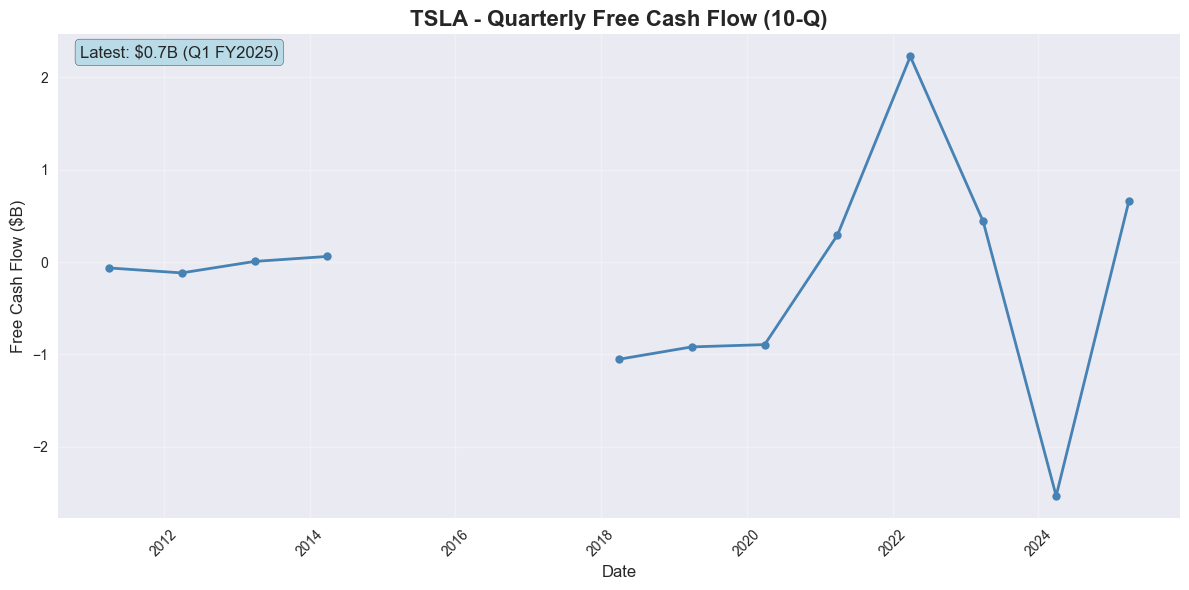

✓ Grafico 10-Q salvato: result/TSLA_fcf_10Q.png


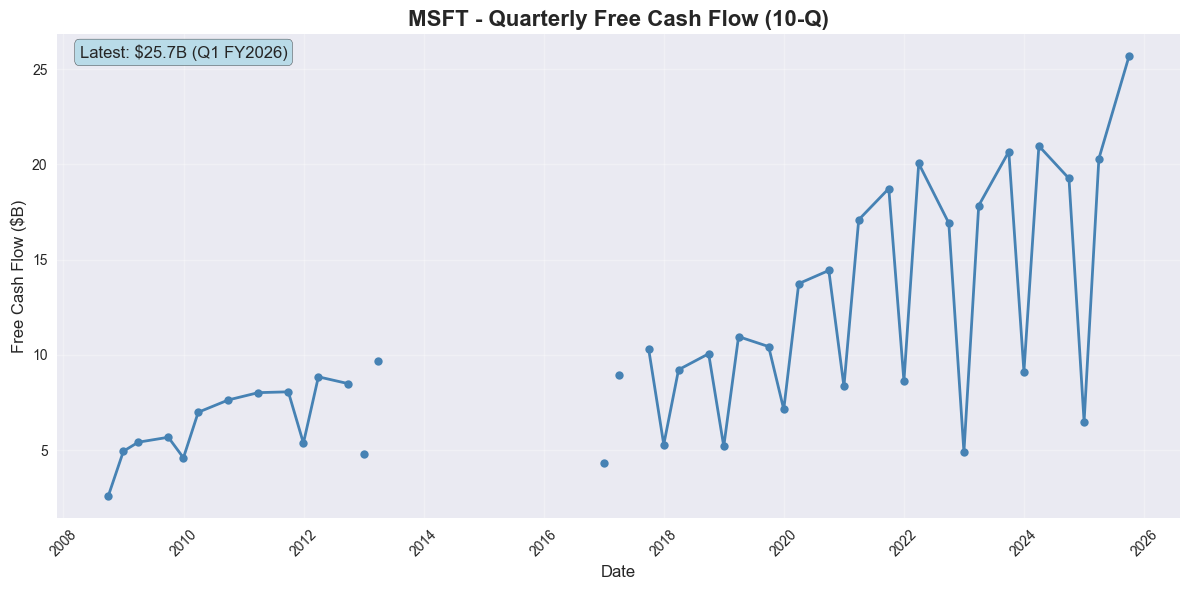

✓ Grafico 10-Q salvato: result/MSFT_fcf_10Q.png


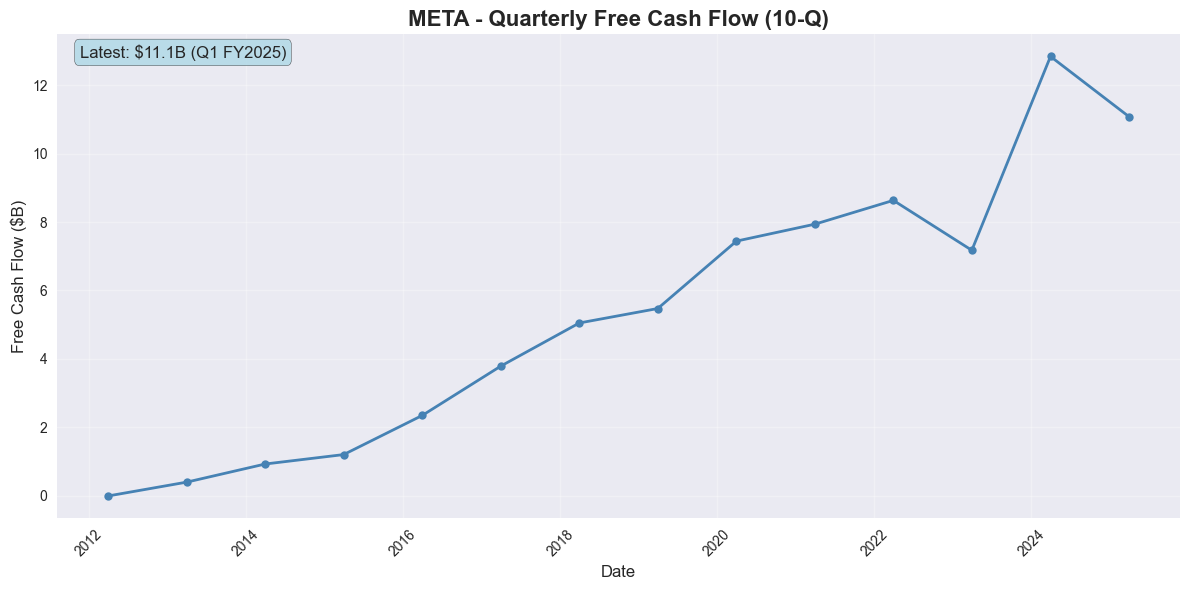

✓ Grafico 10-Q salvato: result/META_fcf_10Q.png


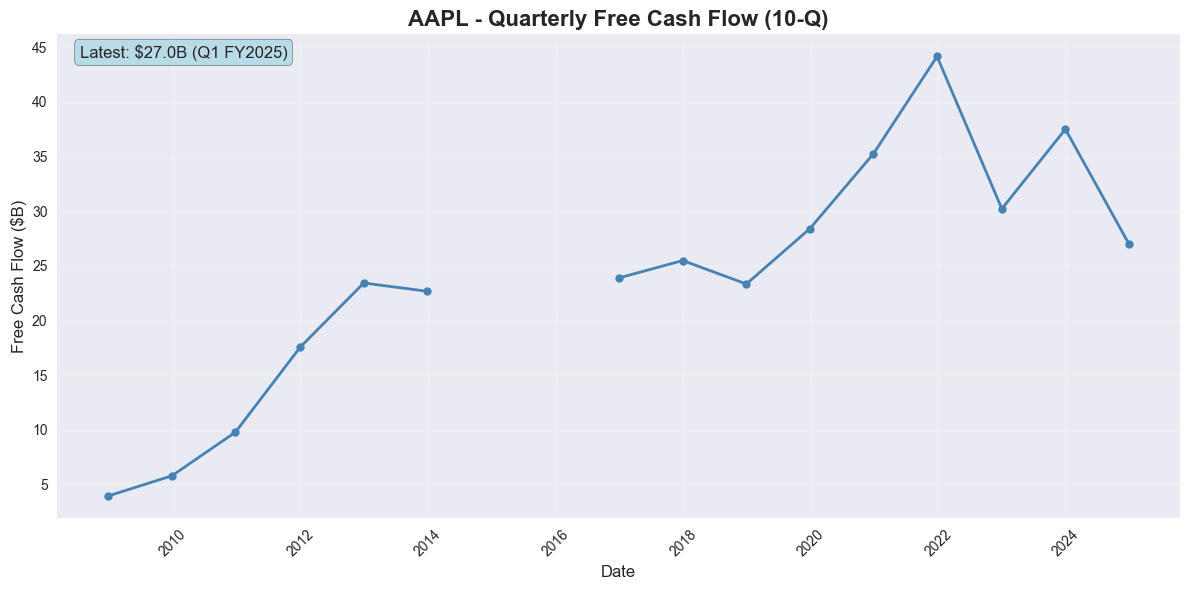

✓ Grafico 10-Q salvato: result/AAPL_fcf_10Q.png


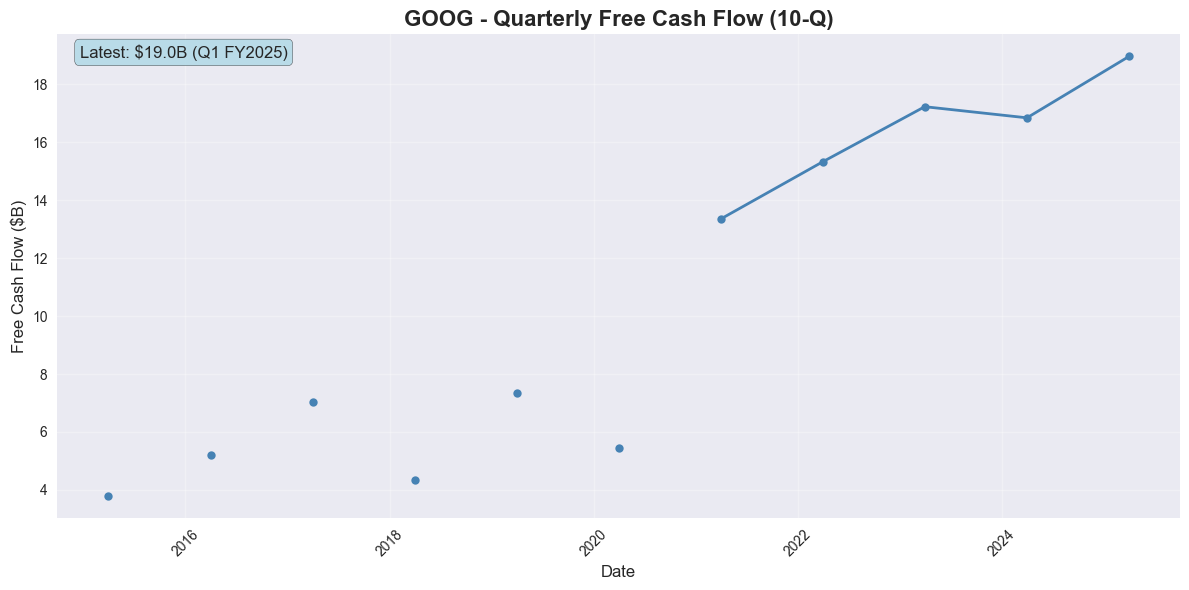

✓ Grafico 10-Q salvato: result/GOOG_fcf_10Q.png


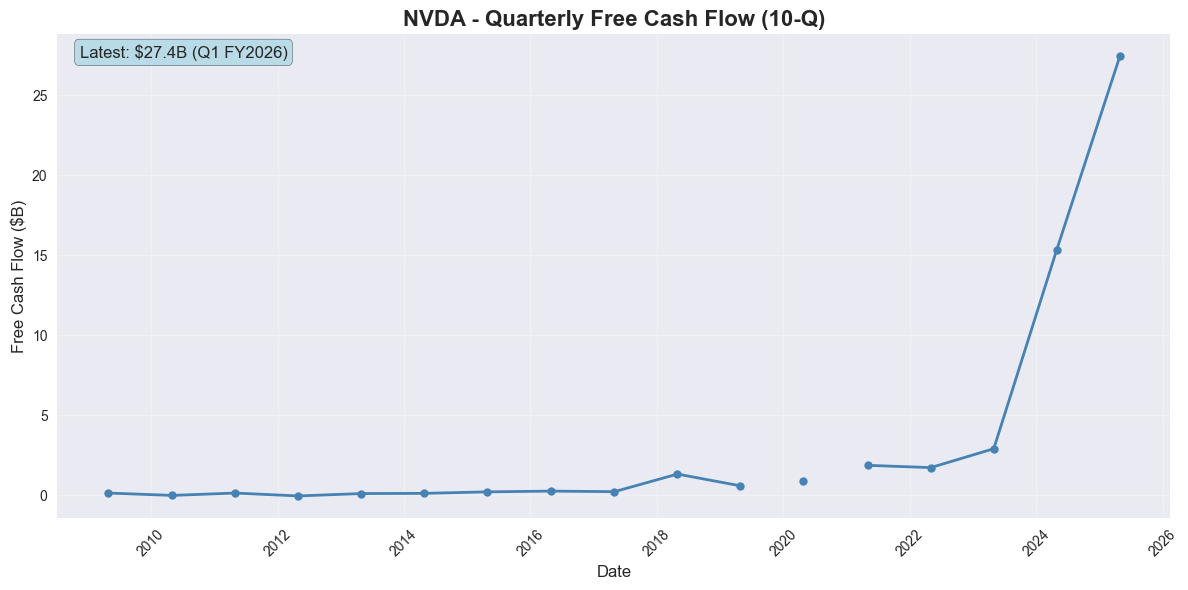

✓ Grafico 10-Q salvato: result/NVDA_fcf_10Q.png


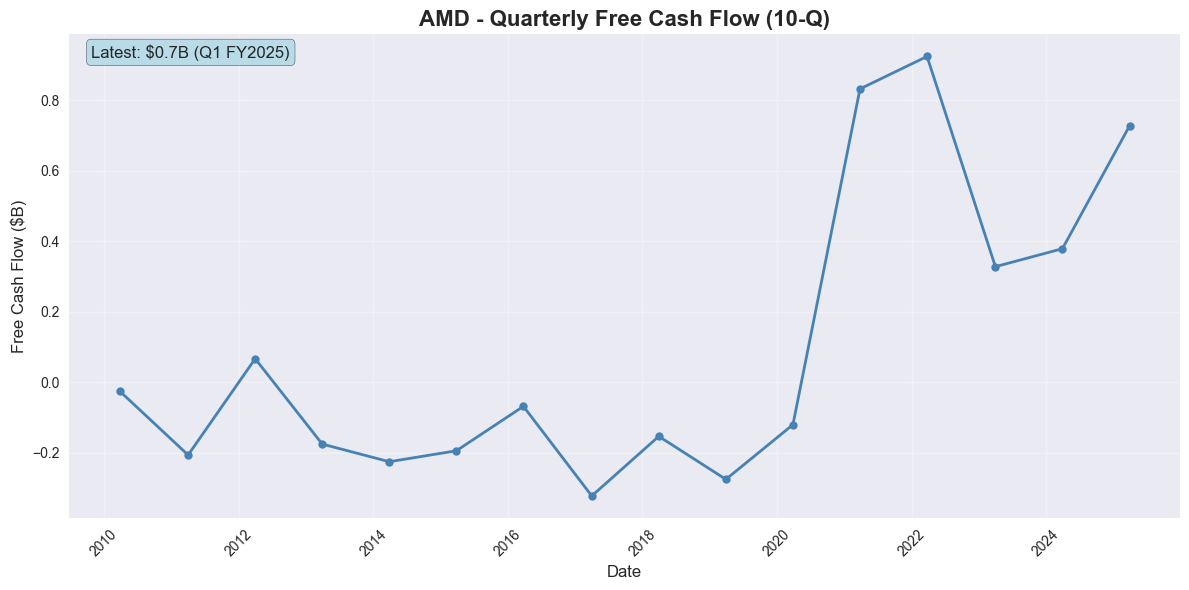

✓ Grafico 10-Q salvato: result/AMD_fcf_10Q.png


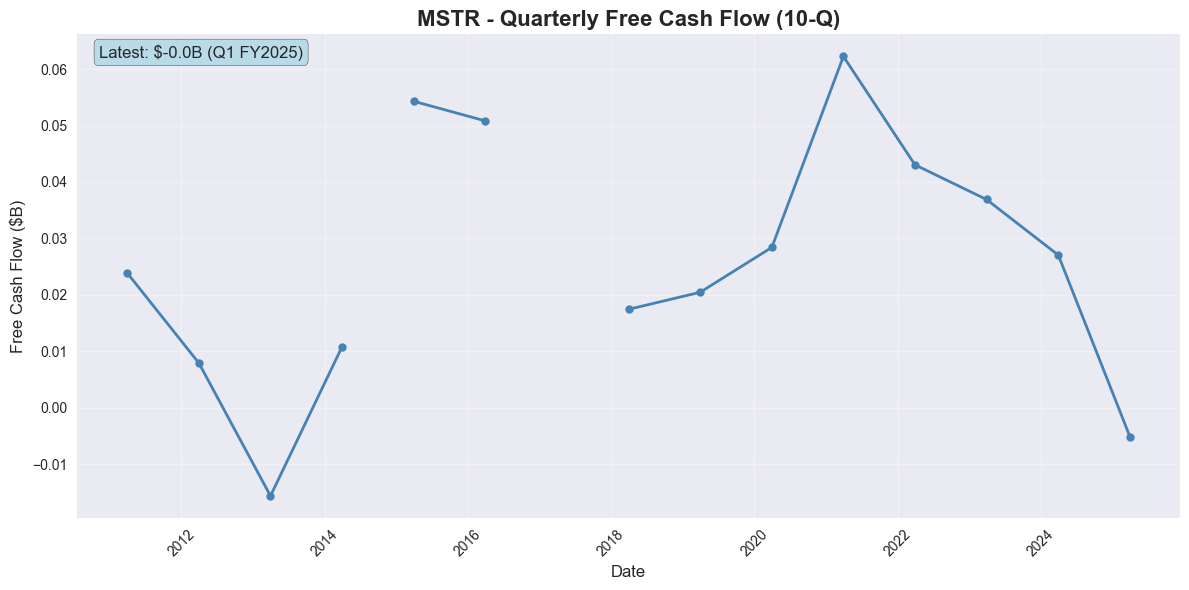

✓ Grafico 10-Q salvato: result/MSTR_fcf_10Q.png


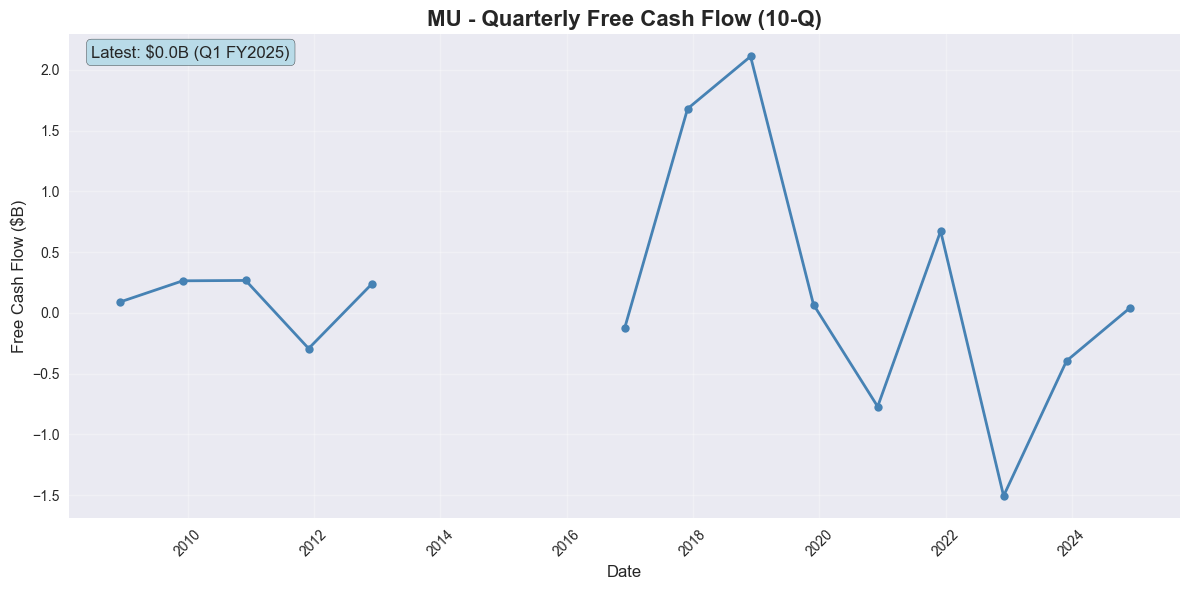

✓ Grafico 10-Q salvato: result/MU_fcf_10Q.png


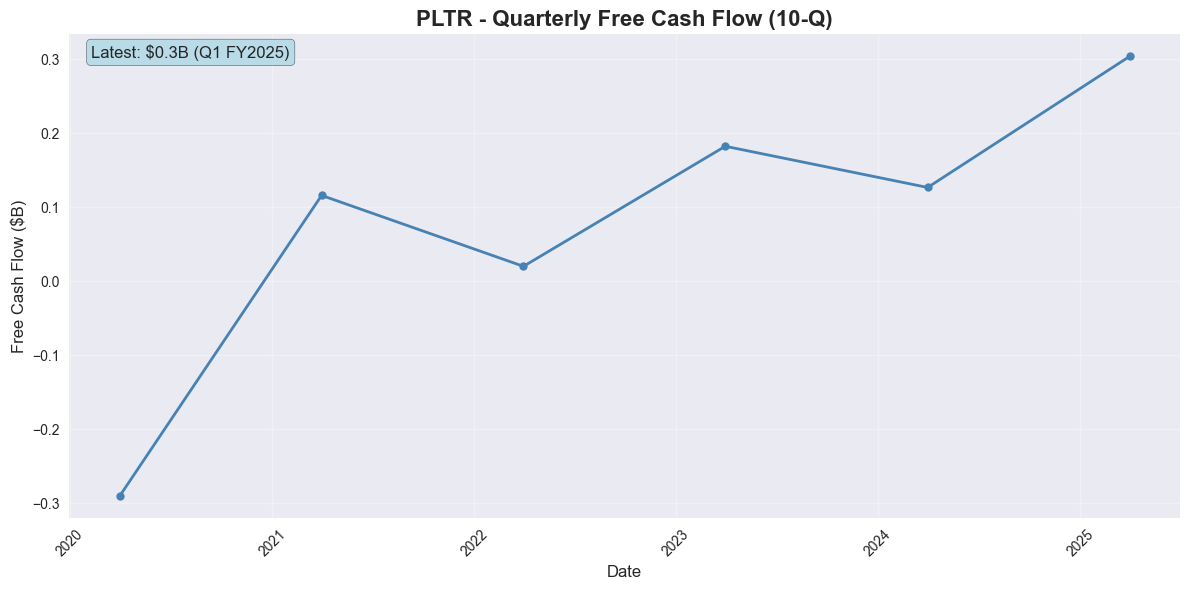

✓ Grafico 10-Q salvato: result/PLTR_fcf_10Q.png


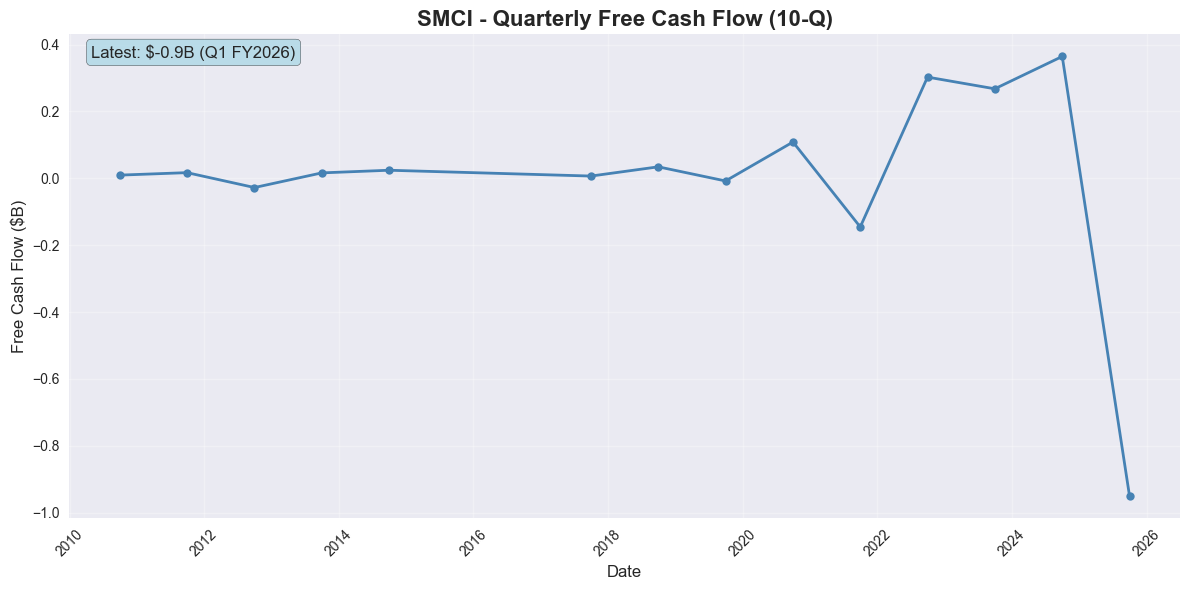

✓ Grafico 10-Q salvato: result/SMCI_fcf_10Q.png

✓ Tutti i grafici trimestrali (10-Q) completati


In [18]:
# PLOT DATI TRIMESTRALI (10-Q)
print("=" * 80)
print("GENERAZIONE GRAFICI TRIMESTRALI (10-Q)")
print("=" * 80)

plt.style.use('seaborn-v0_8')

for ticker in TICKERS:
    filename = f"data/{ticker}_fcf_10Q.csv"

    if os.path.exists(filename):
        # Leggi il CSV
        df = pd.read_csv(filename)

        if not df.empty:
            # Converti date e ordina
            df['end'] = pd.to_datetime(df['end'])
            df = df.sort_values('end')

            # Converti FCF in miliardi
            df['FCF_B'] = df['Free Cash Flow'] / 1_000_000_000

            # Crea plot individuale
            plt.figure(figsize=(12, 6))
            plt.plot(df['end'], df['FCF_B'],
                    marker='o', linewidth=2, markersize=6, color='steelblue')

            plt.title(f'{ticker} - Quarterly Free Cash Flow (10-Q)', fontsize=16, fontweight='bold')
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Free Cash Flow ($B)', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)

            # Aggiungi ultimo valore
            last_value = df['FCF_B'].iloc[-1]
            last_period = df['fp'].iloc[-1]
            last_year = int(df['fy'].iloc[-1])
            plt.text(0.02, 0.98, f'Latest: ${last_value:.1f}B ({last_period} FY{last_year})',
                    transform=plt.gca().transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round',
                    facecolor='lightblue', alpha=0.8))

            plt.tight_layout()
            plt.savefig(f'result/{ticker}_fcf_10Q.png', dpi=300, bbox_inches='tight')
            plt.show()

            print(f"✓ Grafico 10-Q salvato: result/{ticker}_fcf_10Q.png")
        else:
            print(f"⚠ {ticker}: File 10-Q vuoto")
    else:
        print(f"✗ {ticker}: File {filename} non trovato")

print("\n✓ Tutti i grafici trimestrali (10-Q) completati")


GENERAZIONE GRAFICI ANNUALI (10-K)


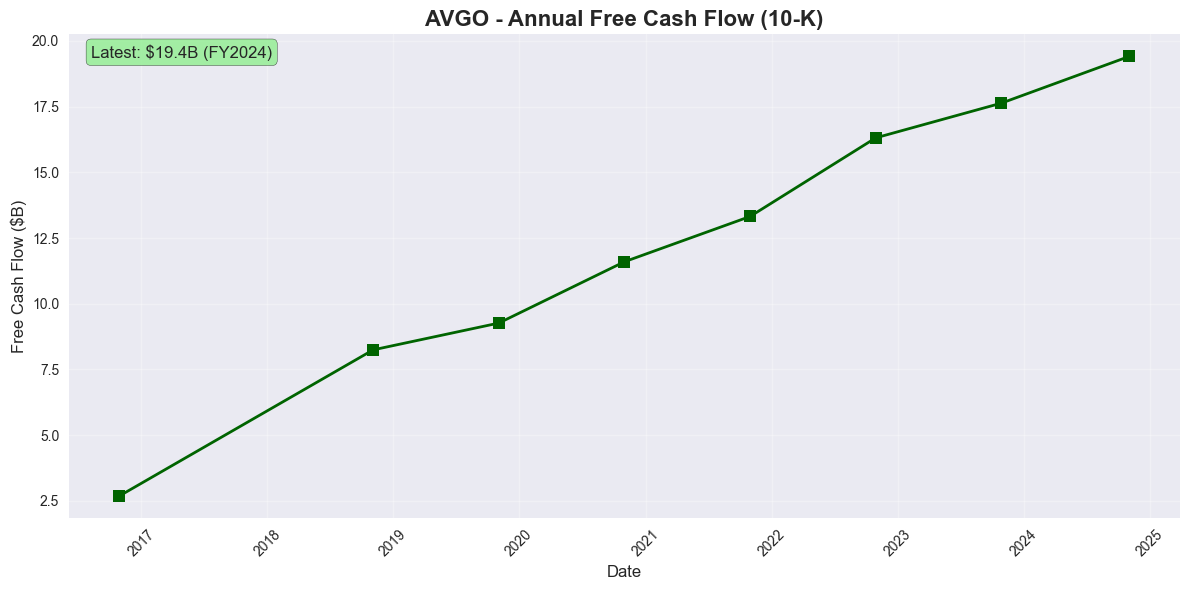

✓ Grafico 10-K salvato: result/AVGO_fcf_10K.png


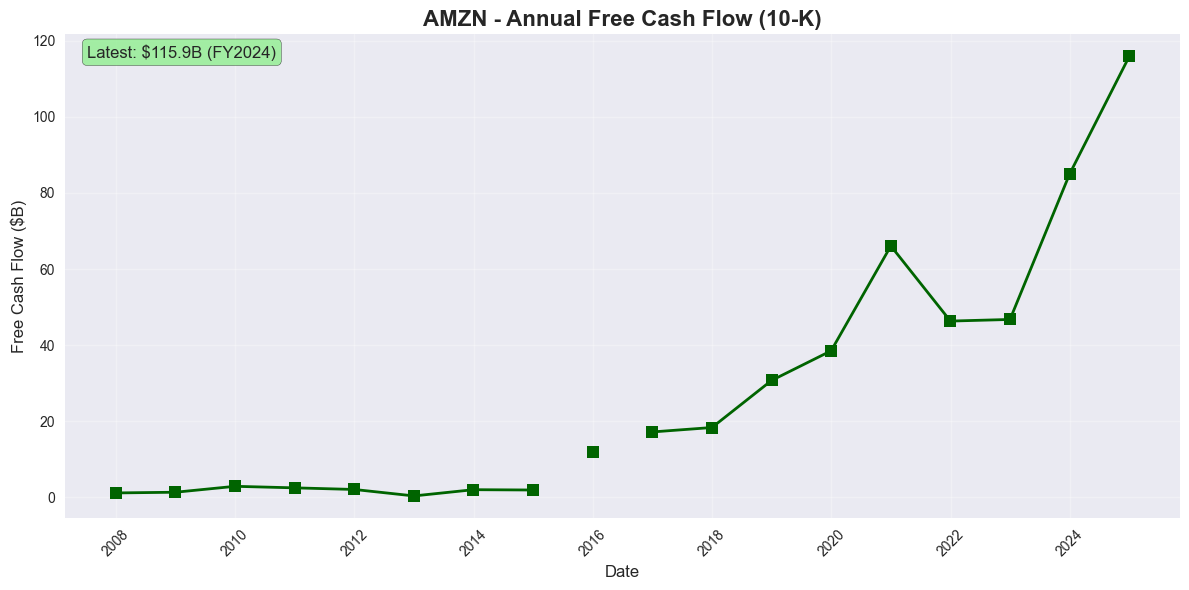

✓ Grafico 10-K salvato: result/AMZN_fcf_10K.png


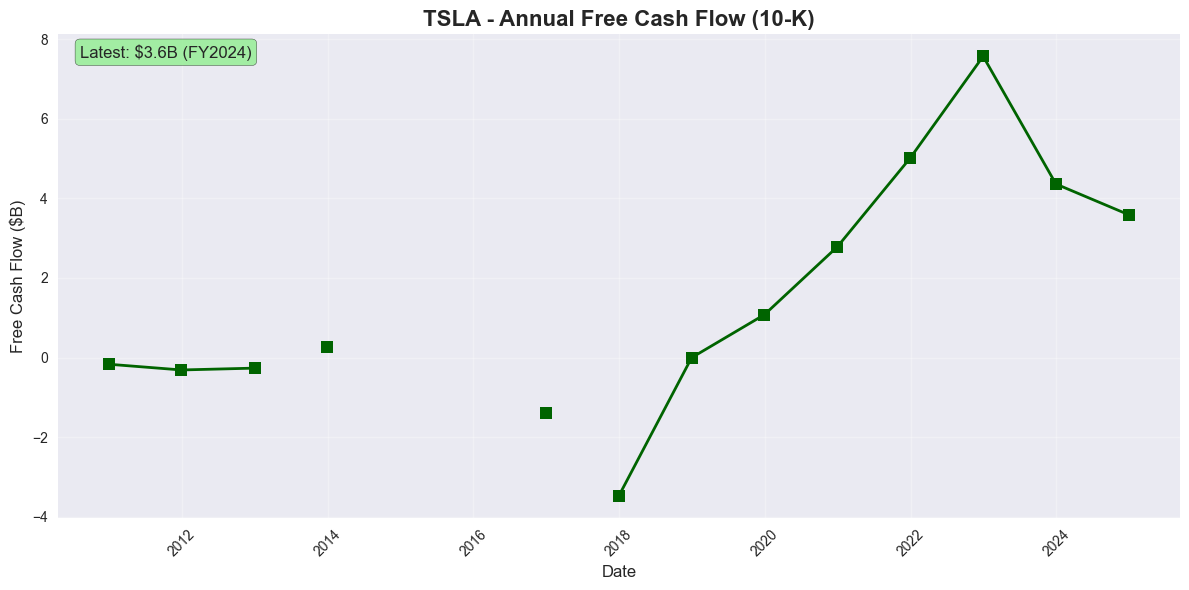

✓ Grafico 10-K salvato: result/TSLA_fcf_10K.png


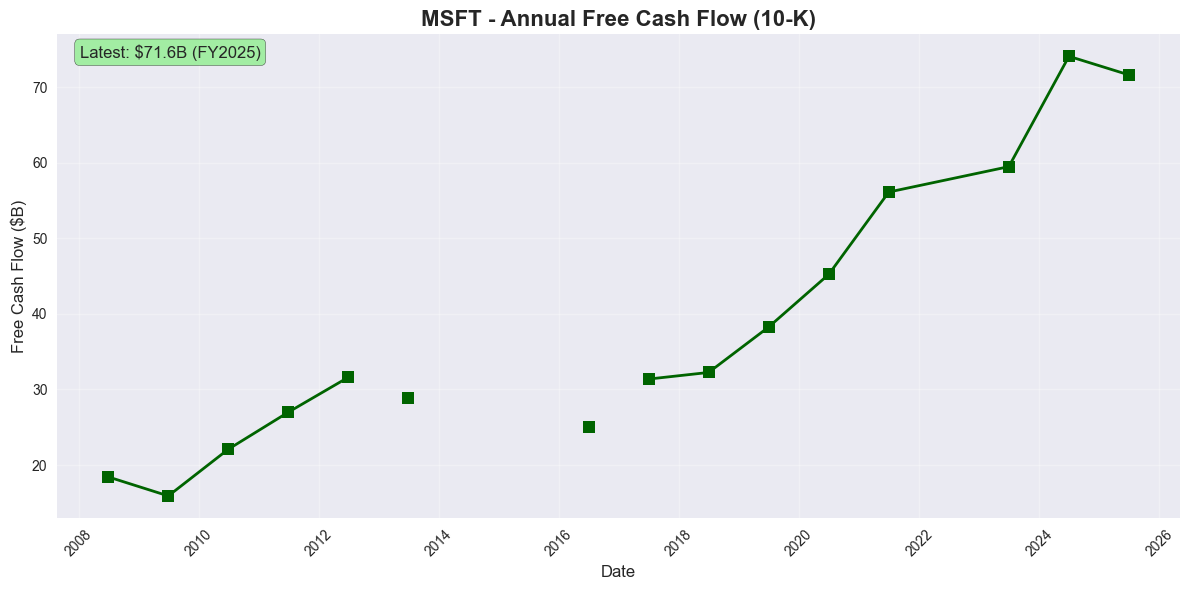

✓ Grafico 10-K salvato: result/MSFT_fcf_10K.png


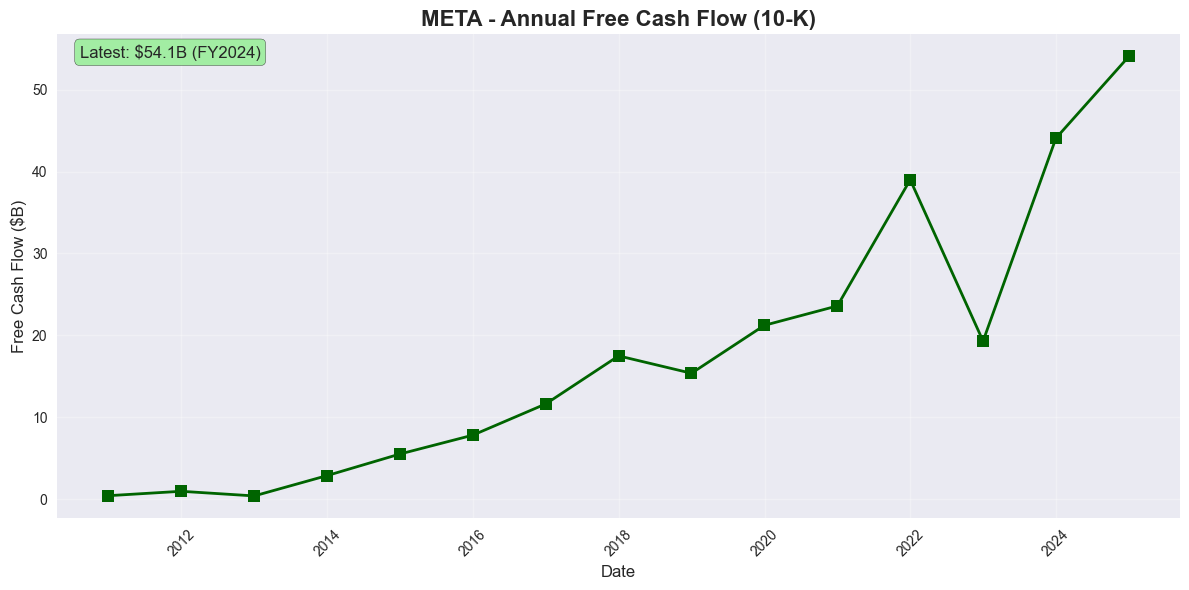

✓ Grafico 10-K salvato: result/META_fcf_10K.png


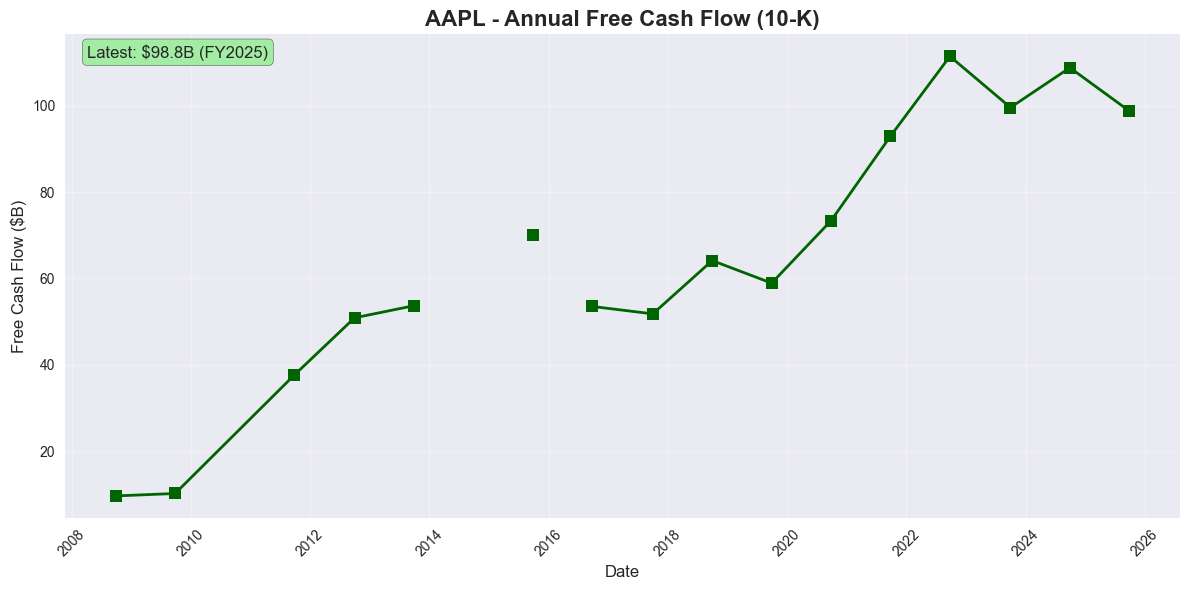

✓ Grafico 10-K salvato: result/AAPL_fcf_10K.png


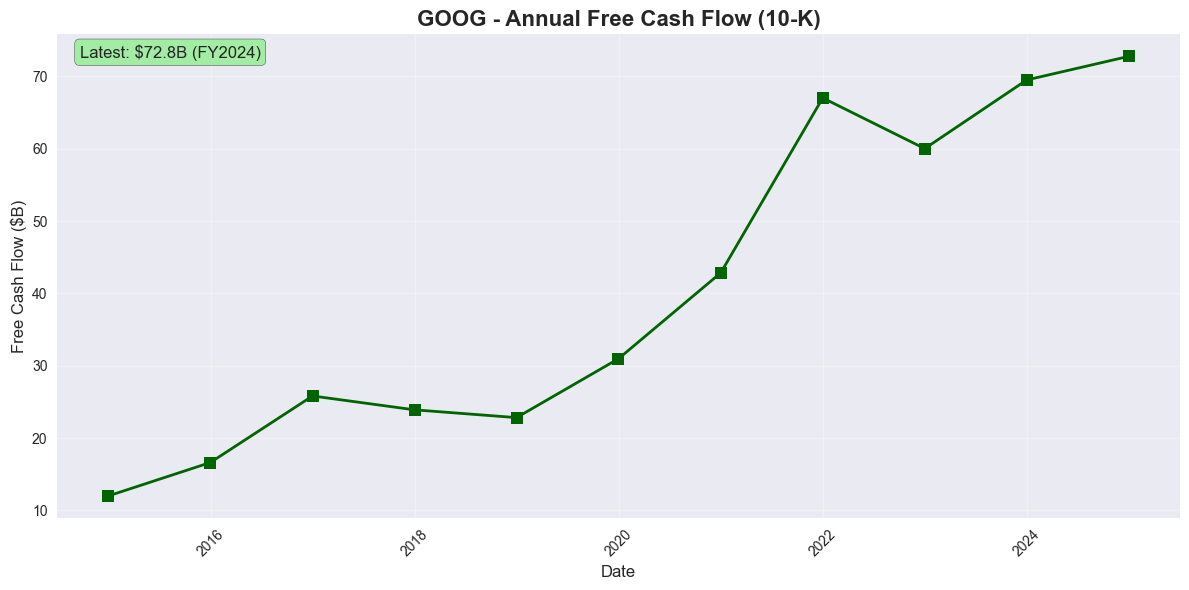

✓ Grafico 10-K salvato: result/GOOG_fcf_10K.png


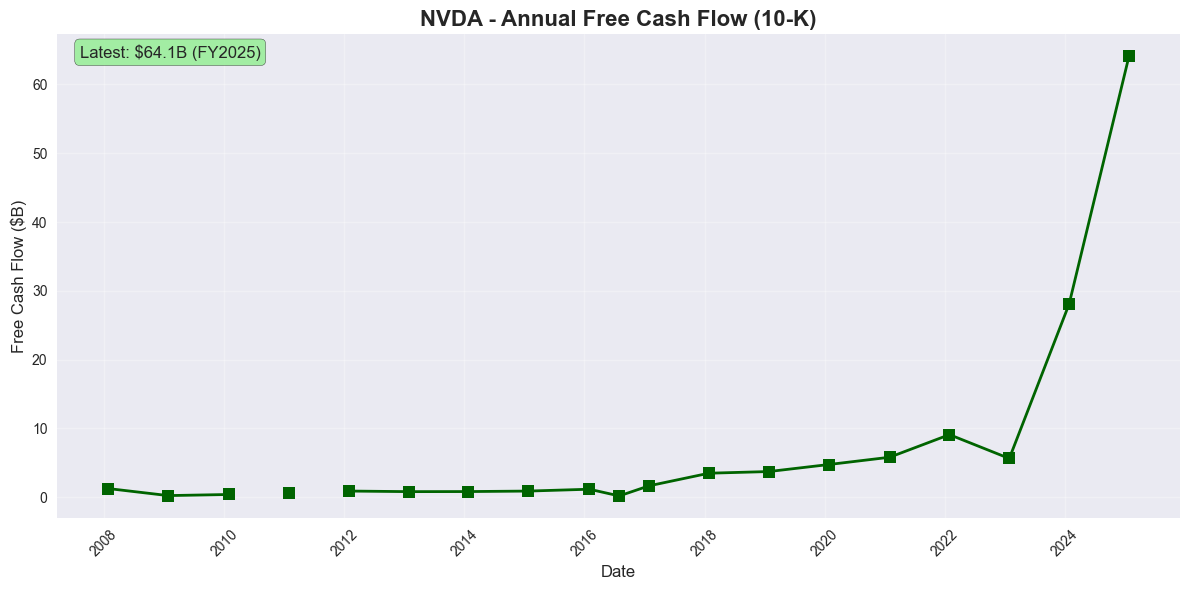

✓ Grafico 10-K salvato: result/NVDA_fcf_10K.png


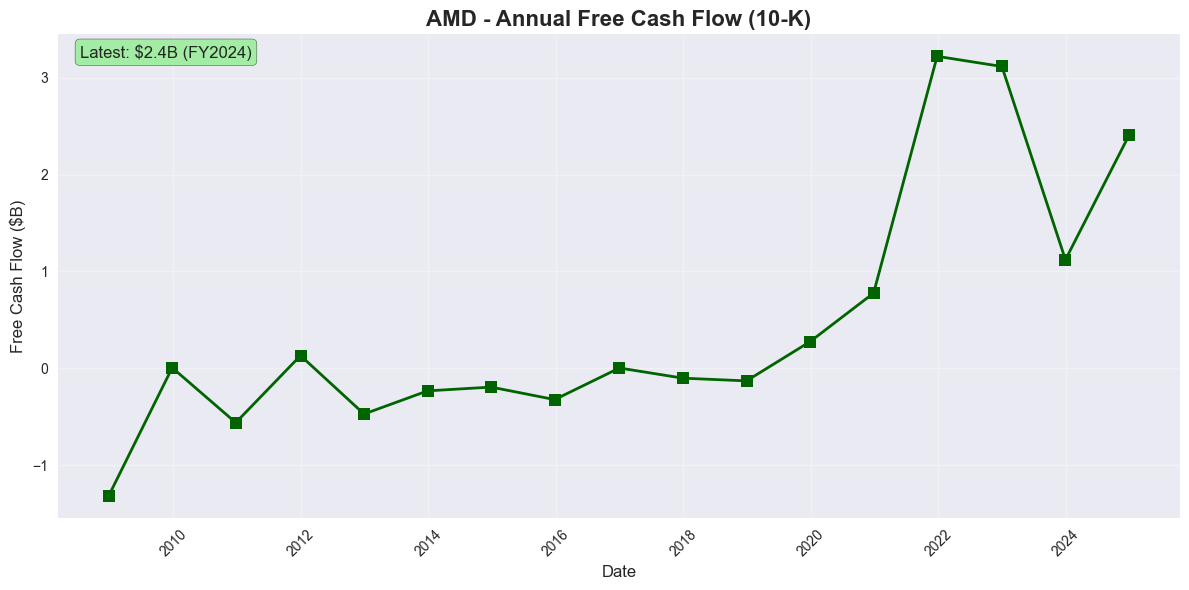

✓ Grafico 10-K salvato: result/AMD_fcf_10K.png


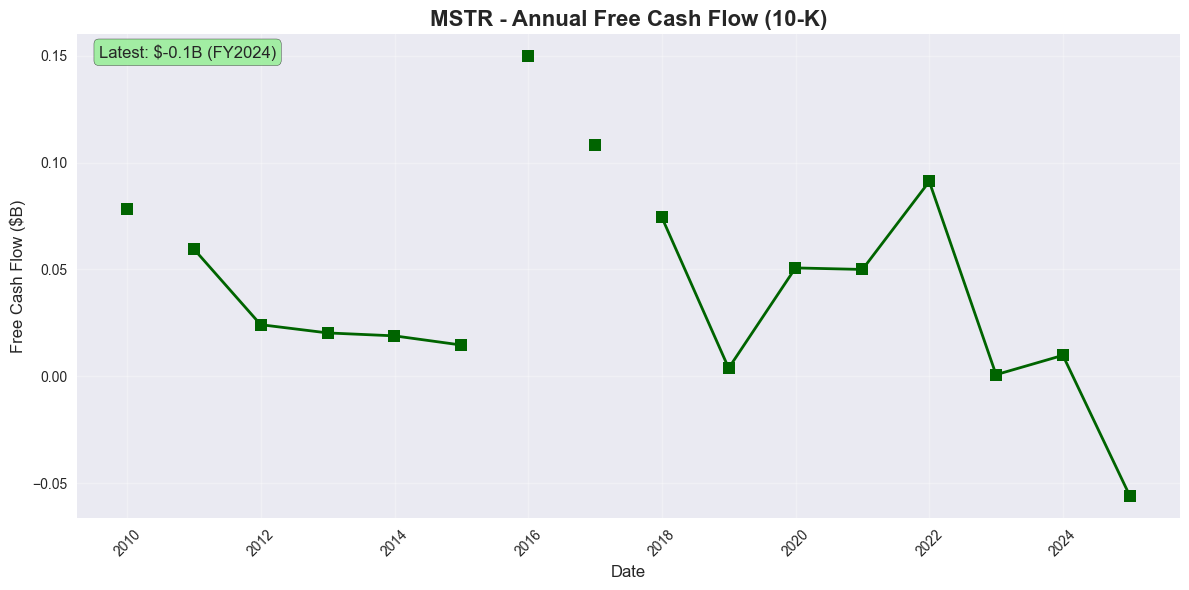

✓ Grafico 10-K salvato: result/MSTR_fcf_10K.png


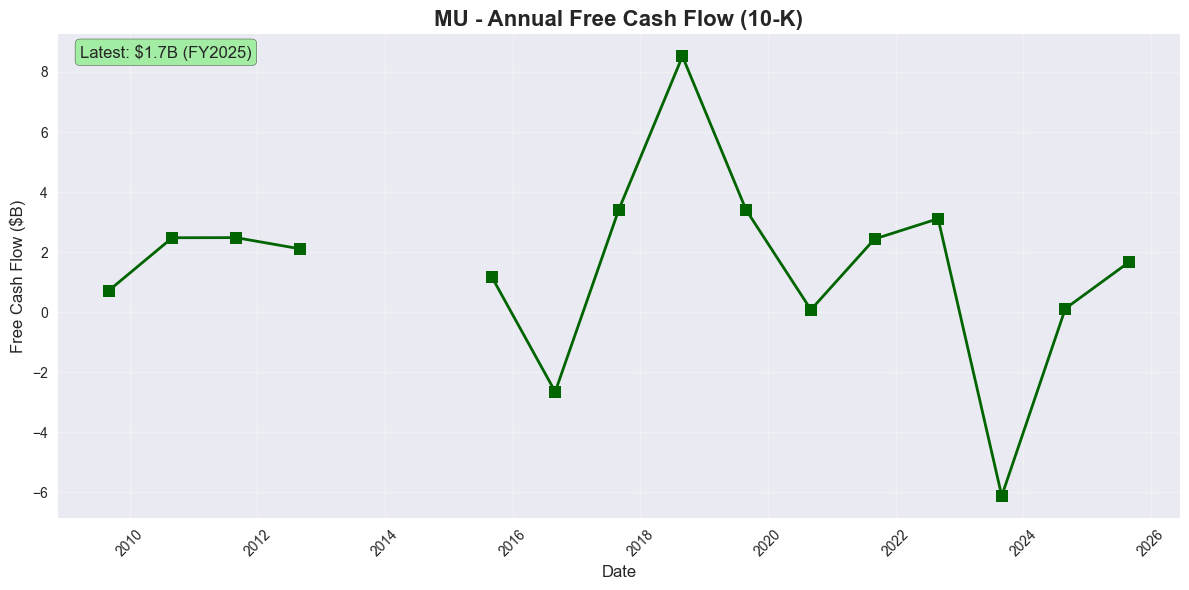

✓ Grafico 10-K salvato: result/MU_fcf_10K.png


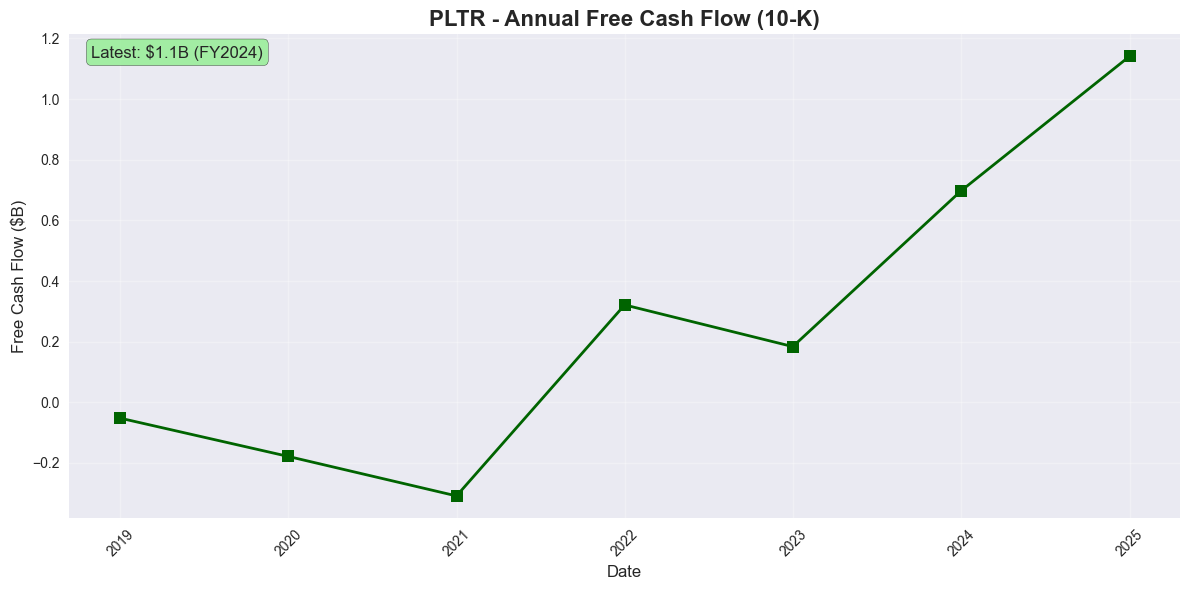

✓ Grafico 10-K salvato: result/PLTR_fcf_10K.png


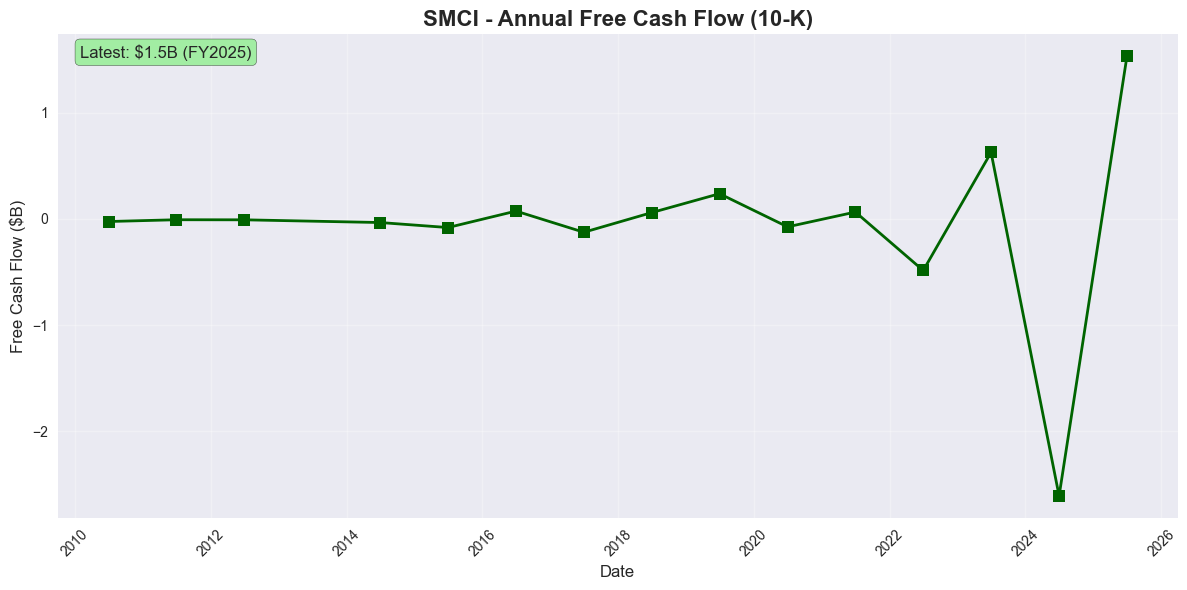

✓ Grafico 10-K salvato: result/SMCI_fcf_10K.png

✓ Tutti i grafici annuali (10-K) completati

ANALISI COMPLETATA


In [19]:
# PLOT DATI ANNUALI (10-K)
print("\n" + "=" * 80)
print("GENERAZIONE GRAFICI ANNUALI (10-K)")
print("=" * 80)

plt.style.use('seaborn-v0_8')

for ticker in TICKERS:
    filename = f"data/{ticker}_fcf_10K.csv"

    if os.path.exists(filename):
        # Leggi il CSV
        df = pd.read_csv(filename)

        if not df.empty:
            # Converti date e ordina
            df['end'] = pd.to_datetime(df['end'])
            df = df.sort_values('end')

            # Converti FCF in miliardi
            df['FCF_B'] = df['Free Cash Flow'] / 1_000_000_000

            # Crea plot individuale
            plt.figure(figsize=(12, 6))
            plt.plot(df['end'], df['FCF_B'],
                    marker='s', linewidth=2, markersize=8, color='darkgreen')

            plt.title(f'{ticker} - Annual Free Cash Flow (10-K)', fontsize=16, fontweight='bold')
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Free Cash Flow ($B)', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)

            # Aggiungi ultimo valore
            last_value = df['FCF_B'].iloc[-1]
            last_year = int(df['fy'].iloc[-1])
            plt.text(0.02, 0.98, f'Latest: ${last_value:.1f}B (FY{last_year})',
                    transform=plt.gca().transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round',
                    facecolor='lightgreen', alpha=0.8))

            plt.tight_layout()
            plt.savefig(f'result/{ticker}_fcf_10K.png', dpi=300, bbox_inches='tight')
            plt.show()

            print(f"✓ Grafico 10-K salvato: result/{ticker}_fcf_10K.png")
        else:
            print(f"⚠ {ticker}: File 10-K vuoto")
    else:
        print(f"✗ {ticker}: File {filename} non trovato")

print("\n✓ Tutti i grafici annuali (10-K) completati")
print("\n" + "=" * 80)
print("ANALISI COMPLETATA")
print("=" * 80)